Notre objectif principal ici est l'étude des résultats liés à la F1 et cela depuis 2009 (date la plus ancienne disponible parmi l'ensemble des données disponibles).

On se penchera à l'observation de **14 tableaux**, tous disponible dans votre ficher sur votre bureau au nom de **donnees_formule_un**.

Le schéma du fichier donne:

**donnees_formule_un/**

├── circuits.csv  
├── constructor_results.csv  
├── constructor_standings.csv  
├── constructors.csv  
├── driver_standings.csv  
├── drivers.csv  
├── lap_times.csv  
├── pit_stops.csv  
├── qualifying.csv  
├── races.csv  
├── results.csv  
├── seasons.csv  
├── sprint_results.csv  
└── status.csv

Si il est complet, et présent sur votre bureau (Desktop), l'exécution de la fonction *charger_donnees_depuis_bureau* du module **import_data** du fichier mère src ne doit pas relever d'erreur.

Si une erreur apparaît, veuillez vérifier que le fichier soit bien sur votre bureau et qu'il est complet. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src import import_data as i_d
i_d.charger_donnees_depuis_bureau()

Dossier trouvé : /Users/charles.ozeel/Desktop/donnees_formule_un
Fichiers CSV trouvés : [PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/circuits.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/status.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/lap_times.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/sprint_results.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/drivers.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/races.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/constructors.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/constructor_standings.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/qualifying.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/driver_standings.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/constructor_results.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees

Chacun des tableaux est chargé dans sa variable du même nom. 

Vous pouvez avoir un aperçu de n'importe laquelle des tables dans la cellule de code ci-dessous.


*On remarquera que le package **Pandas** est déjà importé sous le nom pd avec l'appel de la fonction **i_d.charger_donnees_depuis_bureau**.*

Une fois que toutes tables sont correctement chargées, on va importer les fonctions utiles à l'analyse. 
Chacun des packages est nommé par le nom de son auteur. Ces Packages sont:

**Charles.py**:
*Descriptif des fonctions*

**Jules.py**:
*Descriptif des fonctions*

**Gabriel.py**:
*Descriptif des fonctions*

**Lilian.py**:
*Descriptif des fonctions*

In [3]:
from modules import Charles as charles
from modules import Jules as jules

On va pouvoir commencer par afficher la carte du monde et voir où se place les différents circuits.

L'intérêt ici est d'utiliser **geopandas**, package python qui permet de représenter des données géospatiales.

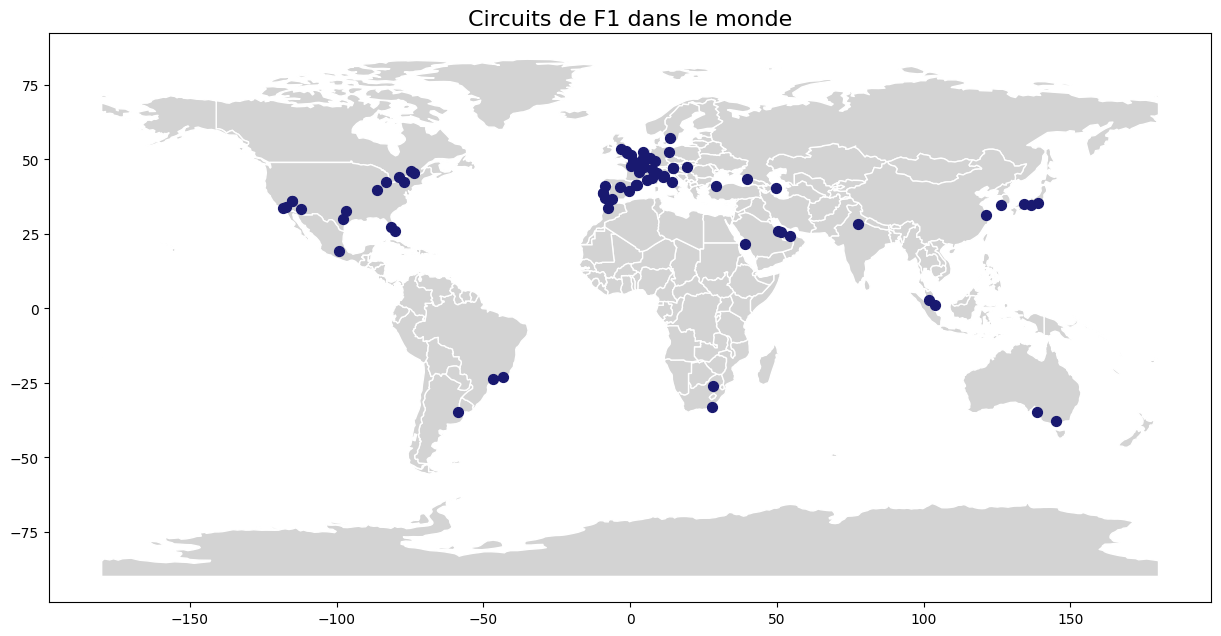

In [4]:
charles.mappage_courses_sans_noms(circuits)

Remarquons que cette fonction marche avec la table circuits, tant qu'elle possède au moins la longitude et lattitude de chaque circuit. 
On peut afficher le nom des circuits avec si le paramètre display est True

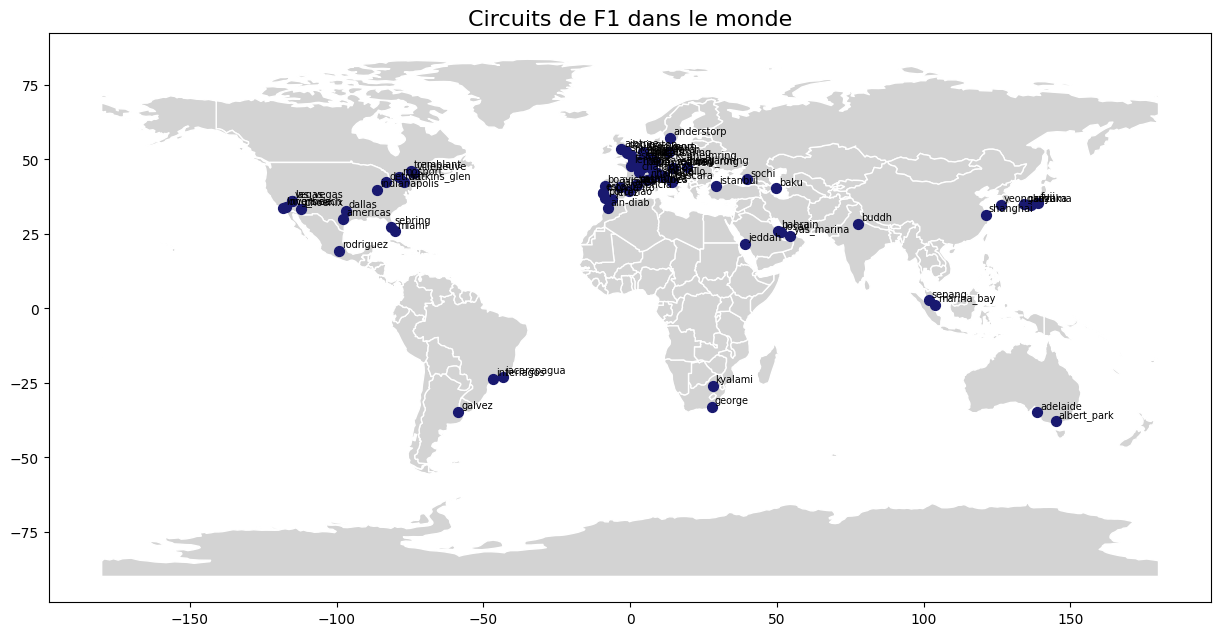

In [5]:
charles.mappage_courses_sans_noms(circuits, True)

Après avoir observé la répartition spatiale, nous allons maintenant étudier le classement des pilotes de manière absolue. L’objectif est de déterminer qui pourrait être considéré comme le meilleur pilote de tous les temps.

Une approche naïve consiste à comparer les pilotes selon leur **nombre total de première position**, ou encore leur **nombre total de points accumulés au cours de leur carrière**.

Pour cela, une première fonction a été développée afin de récupérer le nombre de victoires à partir du nom d’un pilote.

Nous nous intéressons ici au nombre de victoires pour quelques duels emblématiques mentionnés en introduction :

- James Hunt vs Niki Lauda (1976)
- Ayrton Senna vs Alain Prost (1988–1993)
- Lewis Hamilton vs Nico Rosberg (2013–2016)
- Max Verstappen vs Lewis Hamilton (2021)


Remarque :
- Cette fonction a été codée en Python base, sans utiliser de modules externes.
Elle travaille directement sur le dataset sous forme de chaîne de caractères et applique une méthode de type **"groupby"** en s’appuyant sur un **dictionnaire**.
- L'ensemble des fonctions sont appliqués sur le dataframe **results.csv** fusionné avec **drivers.csv** de façon à récuperer le nom des pilotes. (Voir le compte rendu pour plus de détails.)

In [6]:
print('nombre de victoires et de points par joueurs')
print("James Hunt, Nikki Lauda")
print(charles.ttal_vict_pts_pilote("hunt"),charles.ttal_vict_pts_pilote("lauda"))
print("Ayrton Senna, Alain Prost")
print(charles.ttal_vict_pts_pilote("senna"),charles.ttal_vict_pts_pilote("prost"))
print("Lewis Hamilton, Nico Rosberg")
print(charles.ttal_vict_pts_pilote("hamilton"),charles.ttal_vict_pts_pilote("rosberg"))
print("Lewis Hamilton, Max Verstappen")
print(charles.ttal_vict_pts_pilote("hamilton"),charles.ttal_vict_pts_pilote("verstappen"))

nombre de victoires et de points par joueurs
James Hunt, Nikki Lauda
[10, 179.0] [25, 420.5]
Ayrton Senna, Alain Prost
[41, 614.0] [51, 798.5]
Lewis Hamilton, Nico Rosberg
[104, 4713.5] [23, 1594.5]
Lewis Hamilton, Max Verstappen
[104, 4713.5] [0, 17.0]


Remarquons ici que des données manquantes font que Max Verstappen est marqué commec i il n'avait fini aucunes courses en 1ère positions. Un rapide vérification sur Internet nous affirme le contraire.

Après cette première mise en bouche, on peut vouloir voir à quoi ressemble le classement absolue des meilleurs pilotes. Pour ceci on usera habillement des commandes de selections avec le module **pandas** de python comme ci-dessous.



Après avoir analysé ces scores, une question intéressante serait d’examiner la gestion des arrêts aux stands pour chaque pilote. Un **arrêt au stand** (*pit stop*) peut être justifié par des raisons **techniques** (changement de pneus, réparations), ou par des questions **disciplinaires**, notamment en cas de **pénalité**.

Très rapidement, la question du temps gagné ou gagnable sur ce paramètre a poussé chacune des écuries à accélérer les **méthodes d'entretien** des véhicules durant la course. Les pilotes, quant à eux, ont dû éviter les comportements proscrits par le règlement afin de ne pas perdre de temps. En effet, une place peut se perdre à cause d'une milli-seconde perdue.

On cherche donc à observer les statistiques décrivant le mieux l'arrêt au stand des pilotes et voir si une valeur élevée s'associe à un classement bas.

Pour ce faire on utilise la fonction **stat_mean_stop_drivers** qui utilise **table_stat_stop_drivers**. La première fonction **table_stat_stop_drivers** qui génère une table avec le valeur minimal, maximale moyenne passé au stand par course, l'écart type et la moyenne aussi par pilote, la seconde sélectionne la ligne correspondant, tant que le pilote renseigné admet des données. 

Remarque:
- Cette question aura été étudié à l'aide du dataframe **pit_stops.csv** et **drivers.csv**
- Le module **pandas** est à la base de la fonction.

In [9]:
charles.table_stat_stop_drivers(pit_stops, drivers)

,driverRef,duration_min,duration_max,duration_std,duration_mean
0,aitken,24.863000,40.028000,8.527343,30.193000
1,albon,51.434908,154.229184,97.100639,89.600016
2,alguersuari,22.535611,25.130000,1.737174,23.865597
3,alonso,43.170922,156.677463,96.194530,85.659321
4,ambrosio,22.871333,26.688833,2.130518,24.593439
...,...,...,...,...,...
69,vergne,23.598509,46.252509,15.722202,31.414995
70,vettel,27.845924,120.838205,75.711674,61.714135
71,webber,22.015696,26.157232,2.786665,23.553221
72,wehrlein,24.996444,148.526389,99.284295,75.478067


In [10]:
charles.stat_mean_stop_drivers("alonso", pit_stops, drivers)

,driverRef,duration_min,duration_max,duration_std,duration_mean
3,alonso,43.170922,156.677463,96.19453,85.659321


In [11]:
charles.stat_mean_stop_drivers("verstappen", pit_stops, drivers)

ValueError: verstappen est incorrecte, ou il y a des valeurs manquantes liées au pilote recherché.

Enfin nous arrivons à l'application du machin learning sur nos données.  